In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
df = pd.read_csv(
    r"C:\Users\ravsi\Downloads\Conjunto de datos para 2a. evaluación-20260809\breast-cancer.csv"
)
print("Forma:", df.shape)
print("Columnas:", df.columns.tolist()[:8], "...")
print("\nDistribución de diagnosis:")
print(df["diagnosis"].value_counts())
df.head()

Forma: (569, 32)
Columnas: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean'] ...

Distribución de diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
df = df.drop(columns=["id"])

In [3]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [4]:
print("Valores nulos totales:", df.isnull().sum().sum())
print("Distribución numérica de diagnosis:")
print(df["diagnosis"].value_counts())

Valores nulos totales: 0
Distribución numérica de diagnosis:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [6]:
print("\nForma de X:", X.shape)
print("Forma de y:", y.shape)
X.head()


Forma de X: (569, 30)
Forma de y: (569,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape[0])
print("Test :", X_test.shape[0])

Train: 455
Test : 114


In [8]:
modelo = DecisionTreeClassifier(random_state=42)
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
busqueda = GridSearchCV(
    modelo,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
busqueda.fit(X_train, y_train)
print("Mejores hiperparámetros:", busqueda.best_params_)
print("Mejor F1 (validación cruzada):", round(busqueda.best_score_, 4))
mejor_modelo = busqueda.best_estimator_

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
Mejor F1 (validación cruzada): 0.9329


In [9]:
y_pred = mejor_modelo.predict(X_test)
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
print("=== Métricas en conjunto de prueba ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"]))

=== Métricas en conjunto de prueba ===
Accuracy : 0.9386
Precision: 1.0000
Recall   : 0.8333
F1-score : 0.9091

Reporte de clasificación:
              precision    recall  f1-score   support

 Benigno (0)       0.91      1.00      0.95        72
 Maligno (1)       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



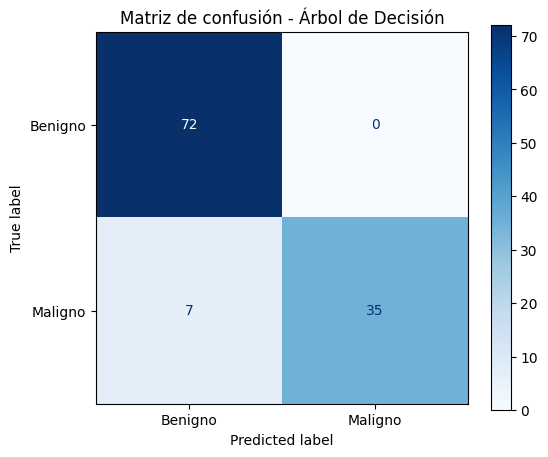

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de confusión - Árbol de Decisión")
plt.show()

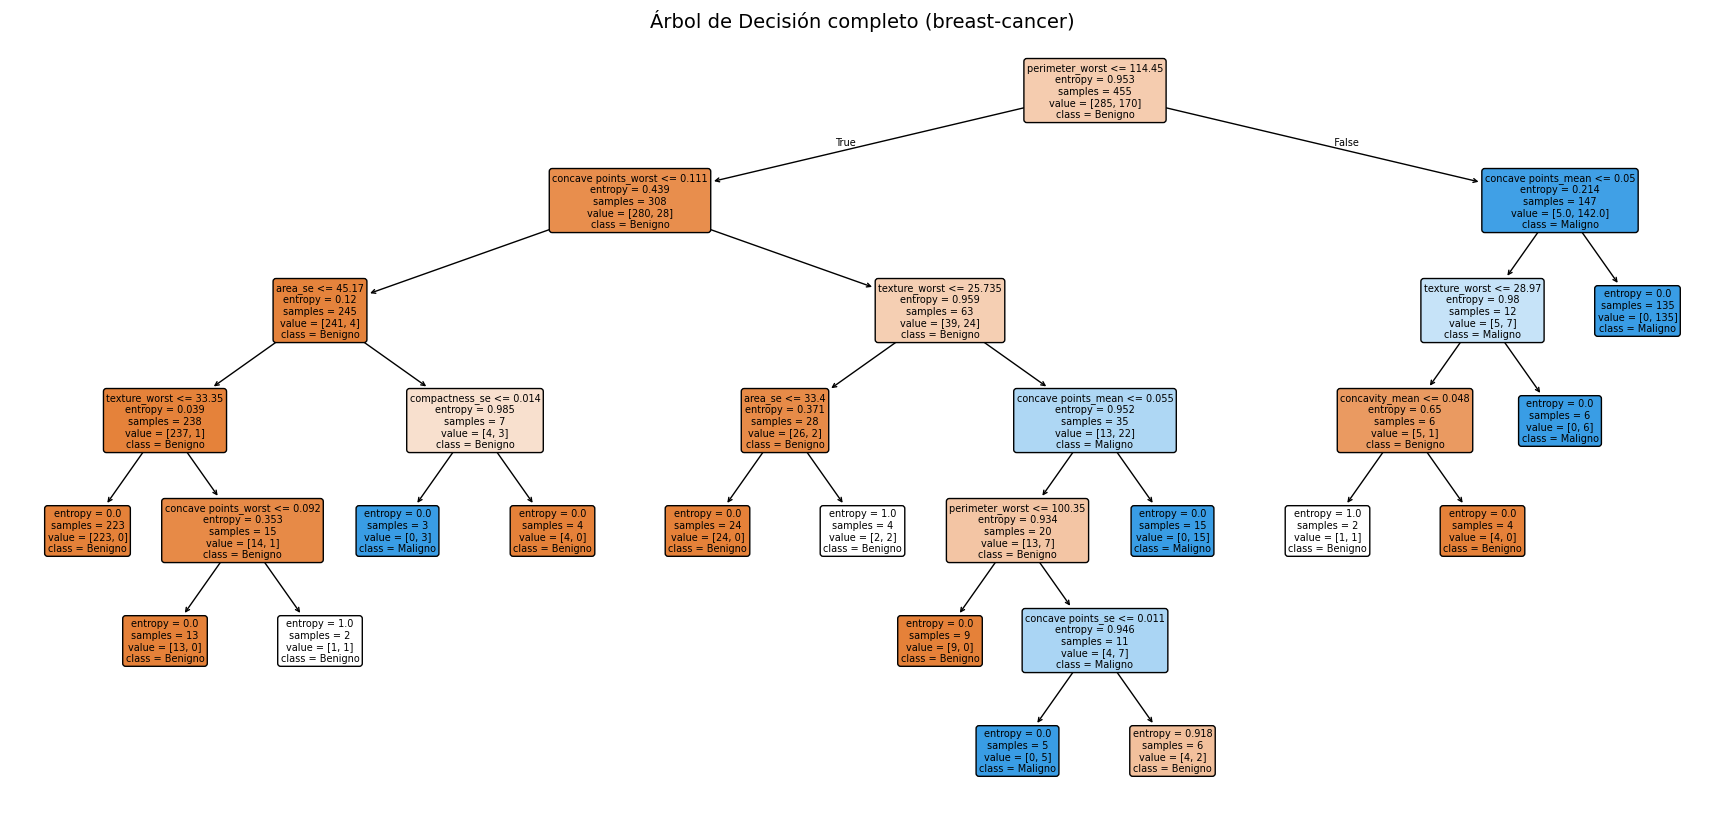

In [11]:
plt.figure(figsize=(22, 10))
plot_tree(
    mejor_modelo,
    feature_names=X.columns,
    class_names=["Benigno", "Maligno"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Árbol de Decisión completo (breast-cancer)", fontsize=14)
plt.show()